In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
train_df = pd.read_csv("../data/processed/train_FD001_labeled.csv")
test_df = pd.read_csv("../data/processed/test_FD001_labeled_final_rows.csv")

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training data shape: (20631, 30)
Test data shape: (100, 30)


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL,risk_label,high_risk_flag
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,192,191,Low Risk,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,192,190,Low Risk,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,192,189,Low Risk,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,192,188,Low Risk,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,192,187,Low Risk,0


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_test_cycle,RUL,risk_label,high_risk_flag
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,...,0.03,393,2388,100.0,38.81,23.3552,31,112,Low Risk,0
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,...,0.03,391,2388,100.0,38.81,23.2618,49,98,Low Risk,0
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,...,0.03,395,2388,100.0,38.93,23.2740,126,69,Medium Risk,0
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,...,0.03,395,2388,100.0,38.58,23.2581,106,82,Low Risk,0
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,...,0.03,394,2388,100.0,38.75,23.4117,98,91,Low Risk,0


In [3]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

feature_columns = (
    ["time_in_cycles"] +
    ["operational_setting_1", "operational_setting_2", "operational_setting_3"] +
    sensor_columns
)

target_column = "high_risk_flag"

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("Number of features:", len(feature_columns))
print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

print("\nTraining target counts:")
display(y_train.value_counts())

print("\nTest target counts:")
display(y_test.value_counts())

Number of features: 25
Training features shape: (20631, 25)
Test features shape: (100, 25)

Training target counts:


high_risk_flag
0    17531
1     3100
Name: count, dtype: int64


Test target counts:


high_risk_flag
0    75
1    25
Name: count, dtype: int64

In [4]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [5]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained.")

Random Forest model trained.


In [6]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }
    
    return metrics

In [7]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)

metrics_df = pd.DataFrame(results)

display(metrics_df)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.93,0.846154,0.88,0.862745,0.979200
1,Random Forest,0.93,0.846154,0.88,0.862745,0.982933


In [8]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, logistic_predictions, target_names=["Not High Risk", "High Risk"]))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_predictions, target_names=["Not High Risk", "High Risk"]))

Logistic Regression Classification Report
               precision    recall  f1-score   support

Not High Risk       0.96      0.95      0.95        75
    High Risk       0.85      0.88      0.86        25

     accuracy                           0.93       100
    macro avg       0.90      0.91      0.91       100
 weighted avg       0.93      0.93      0.93       100


Random Forest Classification Report
               precision    recall  f1-score   support

Not High Risk       0.96      0.95      0.95        75
    High Risk       0.85      0.88      0.86        25

     accuracy                           0.93       100
    macro avg       0.90      0.91      0.91       100
 weighted avg       0.93      0.93      0.93       100



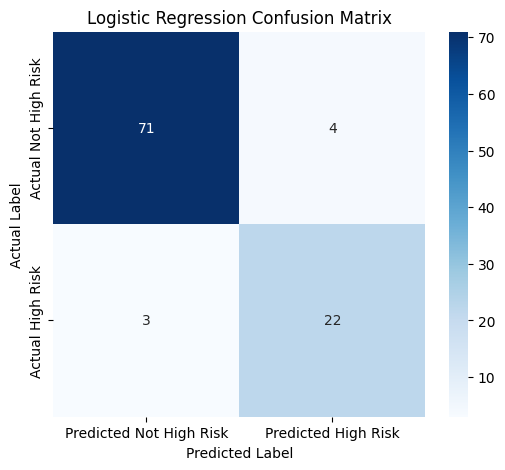

In [9]:
logistic_cm = confusion_matrix(y_test, logistic_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not High Risk", "Predicted High Risk"],
    yticklabels=["Actual Not High Risk", "Actual High Risk"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

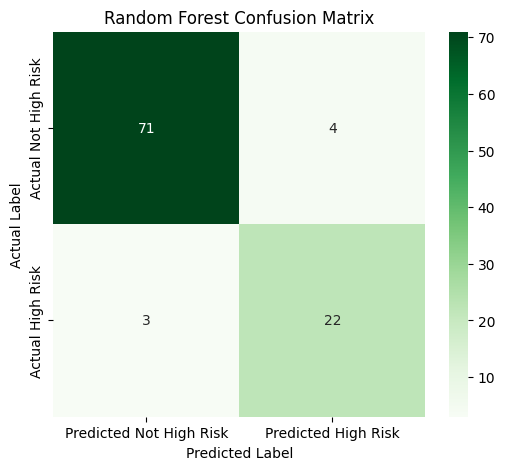

In [10]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted Not High Risk", "Predicted High Risk"],
    yticklabels=["Actual Not High Risk", "Actual High Risk"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [11]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values("importance", ascending=False)

display(feature_importance.head(15))

,feature,importance
14,sensor_11,0.171411
7,sensor_4,0.161406
15,sensor_12,0.154302
10,sensor_7,0.104541
18,sensor_15,0.073512
24,sensor_21,0.064264
23,sensor_20,0.047235
5,sensor_2,0.042051
12,sensor_9,0.039031
17,sensor_14,0.031642


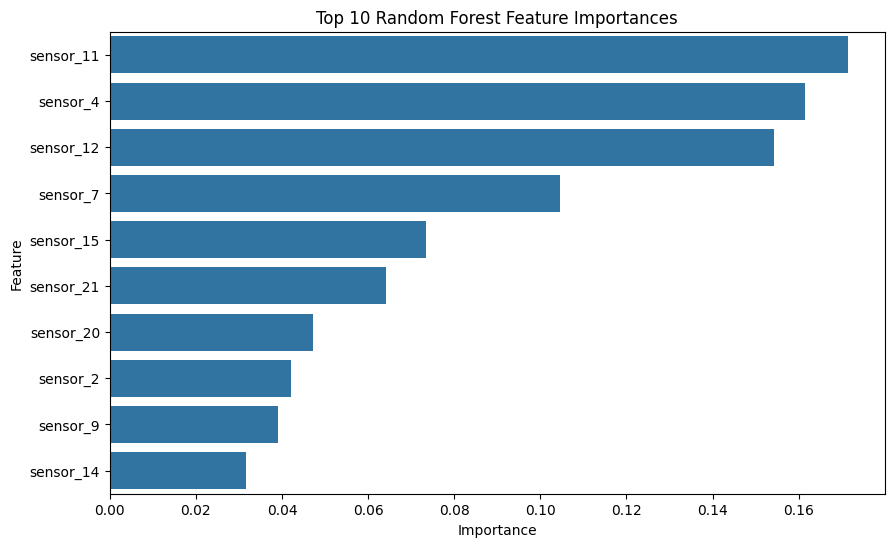

In [12]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [13]:
maintenance_priority = test_df.copy()

maintenance_priority["predicted_high_risk"] = rf_predictions
maintenance_priority["predicted_risk_probability"] = rf_probabilities

maintenance_priority = maintenance_priority[
    [
        "unit_number",
        "time_in_cycles",
        "RUL",
        "risk_label",
        "high_risk_flag",
        "predicted_high_risk",
        "predicted_risk_probability"
    ]
].sort_values("predicted_risk_probability", ascending=False)

display(maintenance_priority.head(20))

,unit_number,time_in_cycles,RUL,risk_label,high_risk_flag,predicted_high_risk,predicted_risk_probability
80,81,213,8,High Risk,1,1,0.994963
33,34,203,7,High Risk,1,1,0.994091
81,82,162,9,High Risk,1,1,0.993649
34,35,198,11,High Risk,1,1,0.993253
48,49,303,21,High Risk,1,1,0.991408
75,76,205,10,High Risk,1,1,0.987727
65,66,147,14,High Risk,1,1,0.980756
67,68,187,8,High Risk,1,1,0.977937
55,56,136,15,High Risk,1,1,0.969520
41,42,156,10,High Risk,1,1,0.965216


In [14]:
maintenance_priority["predicted_risk_label"] = np.where(
    maintenance_priority["predicted_high_risk"] == 1,
    "Predicted High Risk",
    "Predicted Not High Risk"
)

display(maintenance_priority.head(20))

,unit_number,time_in_cycles,RUL,risk_label,high_risk_flag,predicted_high_risk,predicted_risk_probability,predicted_risk_label
80,81,213,8,High Risk,1,1,0.994963,Predicted High Risk
33,34,203,7,High Risk,1,1,0.994091,Predicted High Risk
81,82,162,9,High Risk,1,1,0.993649,Predicted High Risk
34,35,198,11,High Risk,1,1,0.993253,Predicted High Risk
48,49,303,21,High Risk,1,1,0.991408,Predicted High Risk
75,76,205,10,High Risk,1,1,0.987727,Predicted High Risk
65,66,147,14,High Risk,1,1,0.980756,Predicted High Risk
67,68,187,8,High Risk,1,1,0.977937,Predicted High Risk
55,56,136,15,High Risk,1,1,0.969520,Predicted High Risk
41,42,156,10,High Risk,1,1,0.965216,Predicted High Risk


In [15]:
metrics_df.to_csv("../data/outputs/model_metrics.csv", index=False)
feature_importance.to_csv("../data/outputs/feature_importance.csv", index=False)
maintenance_priority.to_csv("../data/outputs/maintenance_priority_table.csv", index=False)

print("Saved model_metrics.csv")
print("Saved feature_importance.csv")
print("Saved maintenance_priority_table.csv")

Saved model_metrics.csv
Saved feature_importance.csv
Saved maintenance_priority_table.csv


# Modeling Summary

In this notebook, I trained two classification models to predict whether a turbofan engine observation was high risk based on operational settings, cycle count, and 21 sensor readings.

The target variable was `high_risk_flag`, where:

- `1` = High Risk engine observation, defined as RUL <= 30
- `0` = Not High Risk, defined as RUL > 30

I trained:

- Logistic Regression as a baseline model
- Random Forest as the final model candidate

Both models achieved strong test performance. Random Forest was selected as the final model because it slightly improved ROC-AUC and provided feature importance, which helps explain which sensor readings contributed most to predicted risk.

The model outputs were exported for dashboarding and reporting, including model metrics, feature importance, and a maintenance priority table ranking test engines by predicted risk probability.

In [16]:
print("Notebook 3 complete.")
print("Final exported files:")
print("- ../data/outputs/model_metrics.csv")
print("- ../data/outputs/feature_importance.csv")
print("- ../data/outputs/maintenance_priority_table.csv")

Notebook 3 complete.
Final exported files:
- ../data/outputs/model_metrics.csv
- ../data/outputs/feature_importance.csv
- ../data/outputs/maintenance_priority_table.csv


In [17]:
import sqlite3
import pandas as pd

In [18]:
train_labeled = pd.read_csv("../data/processed/train_FD001_labeled.csv")
test_labeled = pd.read_csv("../data/processed/test_FD001_labeled_final_rows.csv")

risk_label_counts = pd.read_csv("../data/outputs/risk_label_counts.csv")
rul_summary_by_risk = pd.read_csv("../data/outputs/rul_summary_by_risk.csv")
sensor_change = pd.read_csv("../data/outputs/sensor_change_low_vs_high_risk.csv")
sensor_summary_by_life_stage = pd.read_csv("../data/outputs/sensor_summary_by_life_stage.csv")

model_metrics = pd.read_csv("../data/outputs/model_metrics.csv")
feature_importance = pd.read_csv("../data/outputs/feature_importance.csv")
maintenance_priority = pd.read_csv("../data/outputs/maintenance_priority_table.csv")

print("CSV files loaded successfully.")

CSV files loaded successfully.


In [19]:
db_path = "../data/outputs/aerospace_maintenance.db"

conn = sqlite3.connect(db_path)

print("Database connection created:", db_path)

Database connection created: ../data/outputs/aerospace_maintenance.db


In [20]:
train_labeled.to_sql("train_labeled", conn, if_exists="replace", index=False)
test_labeled.to_sql("test_labeled", conn, if_exists="replace", index=False)

risk_label_counts.to_sql("risk_label_counts", conn, if_exists="replace", index=False)
rul_summary_by_risk.to_sql("rul_summary_by_risk", conn, if_exists="replace", index=False)
sensor_change.to_sql("sensor_change", conn, if_exists="replace", index=False)
sensor_summary_by_life_stage.to_sql("sensor_summary_by_life_stage", conn, if_exists="replace", index=False)

model_metrics.to_sql("model_metrics", conn, if_exists="replace", index=False)
feature_importance.to_sql("feature_importance", conn, if_exists="replace", index=False)
maintenance_priority.to_sql("maintenance_priority", conn, if_exists="replace", index=False)

print("Tables written to SQLite database.")

Tables written to SQLite database.


In [21]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

display(tables)

,name
0,feature_importance
1,maintenance_priority
2,model_metrics
3,risk_label_counts
4,rul_summary_by_risk
5,sensor_change
6,sensor_summary_by_life_stage
7,test_labeled
8,train_labeled


In [22]:
preview = pd.read_sql_query(
    """
    SELECT *
    FROM maintenance_priority
    LIMIT 10;
    """,
    conn
)

display(preview)

,unit_number,time_in_cycles,RUL,risk_label,high_risk_flag,predicted_high_risk,predicted_risk_probability,predicted_risk_label
0,81,213,8,High Risk,1,1,0.994963,Predicted High Risk
1,34,203,7,High Risk,1,1,0.994091,Predicted High Risk
2,82,162,9,High Risk,1,1,0.993649,Predicted High Risk
3,35,198,11,High Risk,1,1,0.993253,Predicted High Risk
4,49,303,21,High Risk,1,1,0.991408,Predicted High Risk
5,76,205,10,High Risk,1,1,0.987727,Predicted High Risk
6,66,147,14,High Risk,1,1,0.980756,Predicted High Risk
7,68,187,8,High Risk,1,1,0.977937,Predicted High Risk
8,56,136,15,High Risk,1,1,0.969520,Predicted High Risk
9,42,156,10,High Risk,1,1,0.965216,Predicted High Risk


In [23]:
conn.close()

print("Database saved and connection closed.")

Database saved and connection closed.
